# Clustering Experiment — 2019–2024 vs. Original 2019–2022

Compare three clustering strategies:
- **Strategy A (Original)**: 22 features (16 means + 6 slopes), Jun 2019–Dec 2021
- **Strategy B (Extended Monthly)**: 19 features (drop 3 annual ACS features), Jun 2019–Dec 2024
- **Strategy C (Model Features)**: 18 RFECV-selected prediction features as means, Jun 2019–Dec 2024

Questions:
1. Does more data or better features improve silhouette over the original 0.11?
2. How many ZIPs change cluster assignment?
3. Do the new archetypes tell a cleaner story?
4. Is a different k better than 5?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.optimize import linear_sum_assignment

pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42

## 1. Feature Sets

In [2]:
# Original 22: 16 means + 6 slopes (matches clustering.ipynb exactly)
ORIG_MEAN = [
    'home_value_index', 'home_value_yoy_pct', 'home_value_mom_12m_avg', 'home_value_accel',
    'pct_sold_above_list', 'avg_sale_to_list_ratio', 'pct_off_market_in_2wks', 'median_days_on_market',
    'inventory', 'inventory_mom_pct', 'inventory_accel',
    'price_to_income_ratio', 'median_household_income', 'owner_occupancy_rate',
    'home_value_vs_baseline', 'sale_price_vs_baseline',
]
ORIG_SLOPE = [
    'home_value_yoy_pct', 'home_value_accel', 'pct_sold_above_list',
    'inventory_mom_pct', 'home_value_vs_baseline', 'sale_price_vs_baseline',
]

# Extended monthly: same but drop 3 annual ACS features (not available beyond 2022)
ANNUAL_FEATS = ['price_to_income_ratio', 'median_household_income', 'owner_occupancy_rate']
EXT_MEAN  = [c for c in ORIG_MEAN  if c not in ANNUAL_FEATS]
EXT_SLOPE = ORIG_SLOPE.copy()

# Model-18: the 18 RFECV-selected features used in prediction (used as means)
MODEL_18 = [
    'homes_sold', 'new_listings', 'inventory', 'median_days_on_market', 'pct_off_market_in_2wks',
    'home_value_mom_pct', 'home_value_yoy_pct', 'inventory_yoy_pct',
    'home_value_mom_3m_avg', 'home_value_mom_12m_avg', 'inventory_mom_12m_avg',
    'home_value_accel', 'home_value_vs_baseline', 'dom_vs_baseline',
    'home_value_mom_pct_lag6', 'pct_sold_above_list_lag6',
    'avg_sale_to_list_ratio_lag6', 'home_value_vs_baseline_lag6',
]

print(f'Strategy A (original 22):      {len(ORIG_MEAN)} means + {len(ORIG_SLOPE)} slopes = {len(ORIG_MEAN)+len(ORIG_SLOPE)} features')
print(f'Strategy B (extended monthly): {len(EXT_MEAN)} means + {len(EXT_SLOPE)} slopes = {len(EXT_MEAN)+len(EXT_SLOPE)} features')
print(f'Strategy C (model-18 means):   {len(MODEL_18)} features')

Strategy A (original 22):      16 means + 6 slopes = 22 features
Strategy B (extended monthly): 13 means + 6 slopes = 19 features
Strategy C (model-18 means):   18 features


## 2. Load Data

In [3]:
# Original dataset — has annual ACS features, Jun 2019–Dec 2023
ds_orig = pd.read_csv('../data/processed/modeling_dataset_with_clusters.csv')
ds_orig['month'] = pd.to_datetime(ds_orig['month'])
ds_orig['zip']   = ds_orig['zip'].astype(str).str.zfill(5)

# Extended features — monthly only, Jun 2019–Dec 2024
ds_ext = pd.read_csv('../data/processed/features_engineered.csv')
ds_ext['month'] = pd.to_datetime(ds_ext['month'])
ds_ext['zip']   = ds_ext['zip'].astype(str).str.zfill(5)

# Original cluster labels (reference point)
zip_labels_orig = pd.read_csv('../data/processed/zip_cluster_labels.csv', index_col=0)
zip_labels_orig.index = zip_labels_orig.index.astype(str).str.zfill(5)
MODEL_ZIPS = set(zip_labels_orig.index)

print(f'Original dataset:  {ds_orig.shape}  {ds_orig["month"].min().date()} to {ds_orig["month"].max().date()}')
print(f'Extended dataset:  {ds_ext.shape}  {ds_ext["month"].min().date()} to {ds_ext["month"].max().date()}')
print(f'Model ZIPs: {len(MODEL_ZIPS)}')

Original dataset:  (36025, 76)  2019-06-30 to 2023-12-31
Extended dataset:  (55944, 68)  2018-01-31 to 2024-12-31
Model ZIPs: 655


## 3. Build ZIP Feature Matrices

In [4]:
def zip_slope(series):
    x = np.arange(len(series))
    if series.isna().any() or len(series) < 2:
        return np.nan
    return np.polyfit(x, series.values, 1)[0]

def build_zip_matrix(df, mean_cols, slope_cols, zip_filter=None):
    """One row per ZIP: means + linear trend slopes."""
    if zip_filter:
        df = df[df['zip'].isin(zip_filter)].copy()
    df = df.dropna(subset=mean_cols + slope_cols)
    means  = df.groupby('zip')[mean_cols].mean()
    means.columns  = [f'{c}_mean'  for c in mean_cols]
    slopes = df.groupby('zip')[slope_cols].agg(zip_slope)
    slopes.columns = [f'{c}_slope' for c in slope_cols]
    return pd.concat([means, slopes], axis=1).dropna()

def build_zip_matrix_flat(df, feature_cols, zip_filter=None):
    """One row per ZIP: means only (for model-18 strategy)."""
    if zip_filter:
        df = df[df['zip'].isin(zip_filter)].copy()
    df = df.dropna(subset=feature_cols)
    return df.groupby('zip')[feature_cols].mean().dropna()

# Strategy A — original window Jun 2019–Dec 2021
ds_a = ds_orig[(ds_orig['month'] >= '2019-06-01') & (ds_orig['month'] <= '2021-12-31')]
mat_a = build_zip_matrix(ds_a, ORIG_MEAN, ORIG_SLOPE, zip_filter=MODEL_ZIPS)

# Strategy B — extended window Jun 2019–Dec 2024, no annual features
ds_b = ds_ext[(ds_ext['month'] >= '2019-06-01') & (ds_ext['month'] <= '2024-12-31')]
mat_b = build_zip_matrix(ds_b, EXT_MEAN, EXT_SLOPE, zip_filter=MODEL_ZIPS)

# Strategy C — model-18 means, Jun 2019–Dec 2024
mat_c = build_zip_matrix_flat(ds_b, MODEL_18, zip_filter=MODEL_ZIPS)

common_zips = sorted(set(mat_a.index) & set(mat_b.index) & set(mat_c.index))
print(f'Matrix A (original 22):      {mat_a.shape}')
print(f'Matrix B (extended monthly): {mat_b.shape}')
print(f'Matrix C (model-18 means):   {mat_c.shape}')
print(f'ZIPs in all three:           {len(common_zips)}')

Matrix A (original 22):      (655, 22)
Matrix B (extended monthly): (655, 19)
Matrix C (model-18 means):   (655, 18)
ZIPs in all three:           655


In [5]:
def scale(mat):
    sc = StandardScaler()
    return sc.fit_transform(mat), sc

X_a, sc_a = scale(mat_a)
X_b, sc_b = scale(mat_b)
X_c, sc_c = scale(mat_c)
print('Scaled all three matrices.')

Scaled all three matrices.


## 4. Silhouette Score vs. k — All Three Strategies

Running silhouette sweep (may take ~60s)...


  A done


  B done


  C done


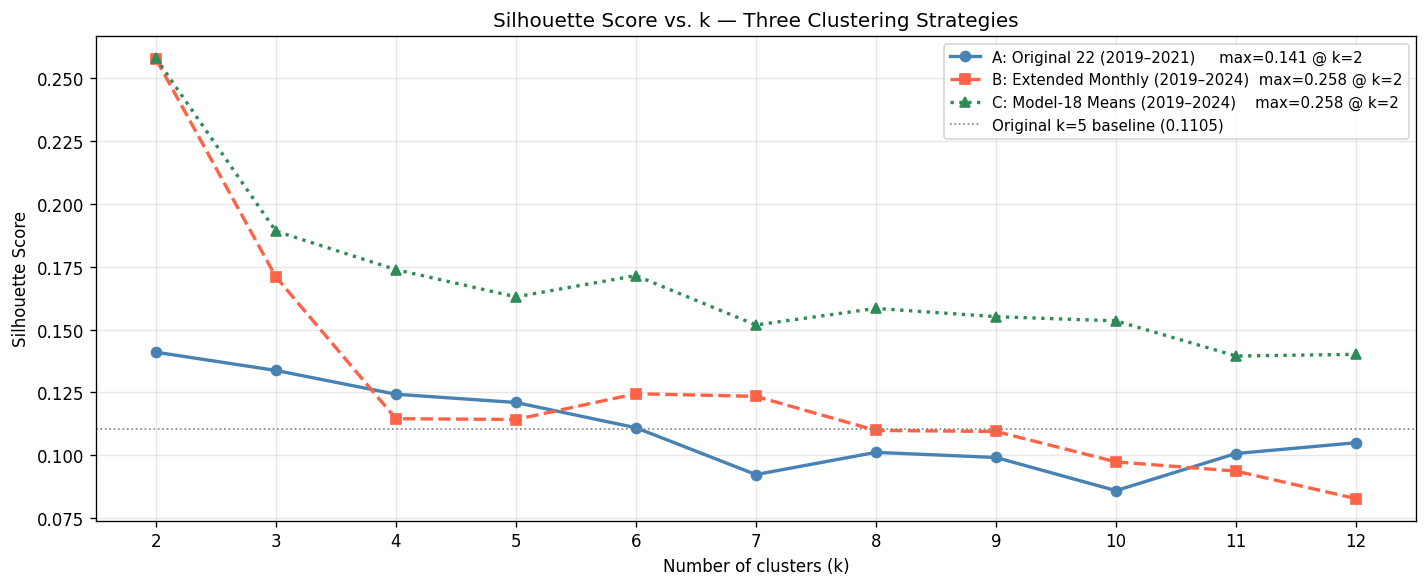


At k=5:
  A: 0.1210  (original was 0.1105)
  B: 0.1142
  C: 0.1630


In [6]:
K_RANGE = range(2, 13)

def silhouette_sweep(X):
    scores = []
    for k in K_RANGE:
        km  = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
        lbl = km.fit_predict(X)
        scores.append(silhouette_score(X, lbl))
    return scores

print('Running silhouette sweep (may take ~60s)...')
sil_a = silhouette_sweep(X_a); print('  A done')
sil_b = silhouette_sweep(X_b); print('  B done')
sil_c = silhouette_sweep(X_c); print('  C done')

k_list = list(K_RANGE)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(k_list, sil_a, 'o-',  color='steelblue', lw=2, label=f'A: Original 22 (2019–2021)     max={max(sil_a):.3f} @ k={k_list[sil_a.index(max(sil_a))]}')
ax.plot(k_list, sil_b, 's--', color='tomato',    lw=2, label=f'B: Extended Monthly (2019–2024)  max={max(sil_b):.3f} @ k={k_list[sil_b.index(max(sil_b))]}')
ax.plot(k_list, sil_c, '^:',  color='seagreen',  lw=2, label=f'C: Model-18 Means (2019–2024)    max={max(sil_c):.3f} @ k={k_list[sil_c.index(max(sil_c))]}')
ax.axhline(0.1105, color='gray', lw=1, ls=':', label='Original k=5 baseline (0.1105)')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score vs. k — Three Clustering Strategies')
ax.set_xticks(k_list)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nAt k=5:')
print(f'  A: {sil_a[3]:.4f}  (original was 0.1105)')
print(f'  B: {sil_b[3]:.4f}')
print(f'  C: {sil_c[3]:.4f}')

## 5. Fit k=5 for All Three — Cluster Assignment Overlap

In [7]:
K = 5
km_a = KMeans(n_clusters=K, n_init=50, max_iter=500, random_state=RANDOM_STATE).fit(X_a)
km_b = KMeans(n_clusters=K, n_init=50, max_iter=500, random_state=RANDOM_STATE).fit(X_b)
km_c = KMeans(n_clusters=K, n_init=50, max_iter=500, random_state=RANDOM_STATE).fit(X_c)

idx_a = {z: i for i, z in enumerate(mat_a.index)}
idx_b = {z: i for i, z in enumerate(mat_b.index)}
idx_c = {z: i for i, z in enumerate(mat_c.index)}

df_cmp = pd.DataFrame({
    'zip':   common_zips,
    'lbl_a': [km_a.labels_[idx_a[z]] for z in common_zips],
    'lbl_b': [km_b.labels_[idx_b[z]] for z in common_zips],
    'lbl_c': [km_c.labels_[idx_c[z]] for z in common_zips],
})

def best_match_rate(ref, new):
    """Optimally relabel cluster IDs then compute fraction that agree."""
    k = max(ref.max(), new.max()) + 1
    cost = np.zeros((k, k), dtype=int)
    for r, n in zip(ref, new):
        cost[r, n] += 1
    r_idx, c_idx = linear_sum_assignment(-cost)
    return cost[r_idx, c_idx].sum() / len(ref)

rate_ab = best_match_rate(df_cmp['lbl_a'].values, df_cmp['lbl_b'].values)
rate_ac = best_match_rate(df_cmp['lbl_a'].values, df_cmp['lbl_c'].values)

n = len(common_zips)
print(f'ZIP assignment agreement (optimal cluster relabelling):')
print(f'  A vs B (extended monthly): {rate_ab:.1%} agree  -> {round((1-rate_ab)*n)} ZIPs changed')
print(f'  A vs C (model-18):         {rate_ac:.1%} agree  -> {round((1-rate_ac)*n)} ZIPs changed')

ZIP assignment agreement (optimal cluster relabelling):
  A vs B (extended monthly): 58.6% agree  -> 271 ZIPs changed
  A vs C (model-18):         47.3% agree  -> 345 ZIPs changed


## 6. PCA Visualisation — Side by Side

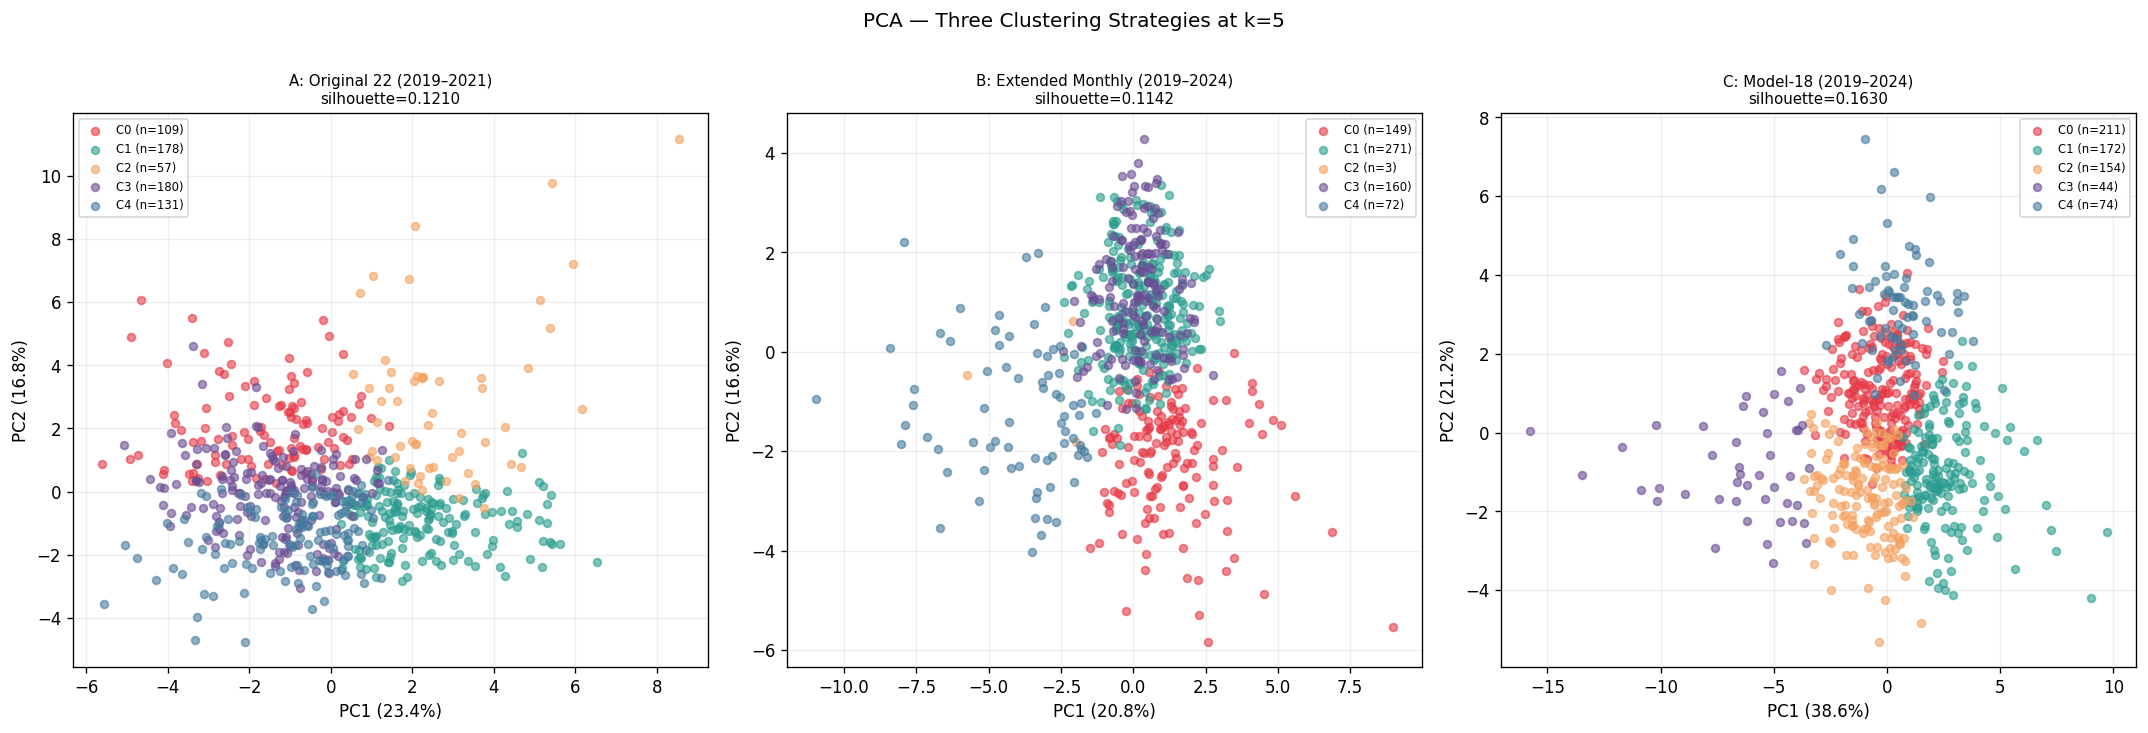

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
titles = ['A: Original 22 (2019–2021)', 'B: Extended Monthly (2019–2024)', 'C: Model-18 (2019–2024)']
Xs   = [X_a,          X_b,          X_c]
lbls = [km_a.labels_, km_b.labels_, km_c.labels_]
sils = [sil_a[3],     sil_b[3],     sil_c[3]]
colors = ['#e63946', '#2a9d8f', '#f4a261', '#6a4c93', '#457b9d']

for ax, X, lbl, title, sil in zip(axes, Xs, lbls, titles, sils):
    pca    = PCA(n_components=2, random_state=RANDOM_STATE)
    coords = pca.fit_transform(X)
    for k_id in range(K):
        mask = lbl == k_id
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=colors[k_id], alpha=0.6, s=22, label=f'C{k_id} (n={mask.sum()})')
    ax.set_title(f'{title}\nsilhouette={sil:.4f}', fontsize=9)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.2)

plt.suptitle('PCA — Three Clustering Strategies at k=5', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 7. Cluster Profiles — Best Strategy at k=5

Best strategy at k=5: C (Model-18)  silhouette=0.1630


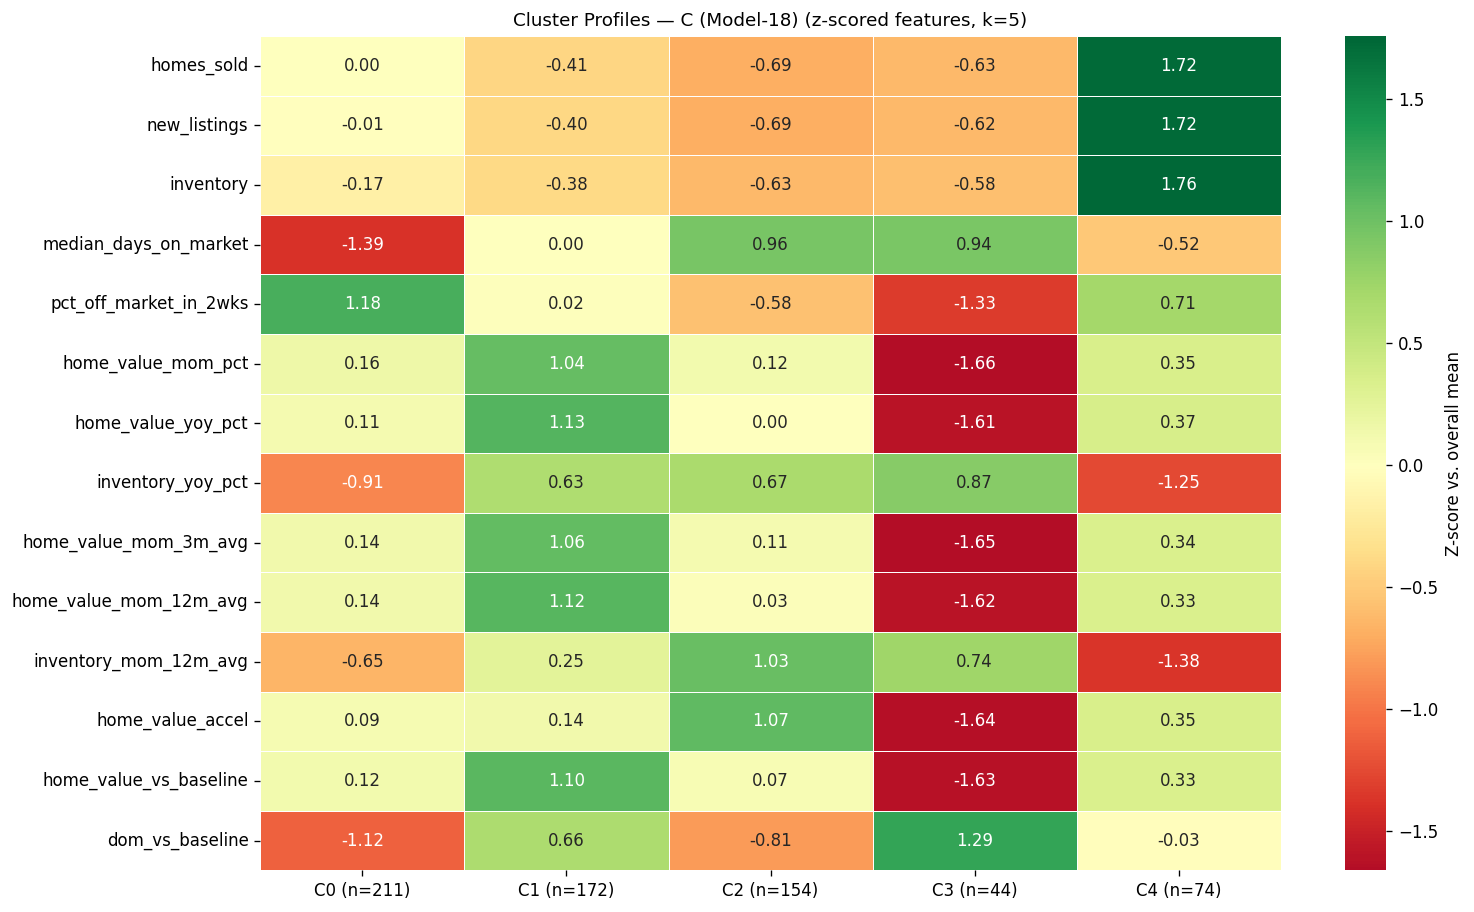


Cluster sizes:
0    211
1    172
2    154
3     44
4     74
Name: count, dtype: int64


In [9]:
sils_at_5 = [sil_a[3], sil_b[3], sil_c[3]]
best_idx  = int(np.argmax(sils_at_5))
best_name = ['A (Original 22)', 'B (Extended Monthly)', 'C (Model-18)'][best_idx]
best_X    = [X_a, X_b, X_c][best_idx]
best_mat  = [mat_a, mat_b, mat_c][best_idx]
best_lbl  = [km_a.labels_, km_b.labels_, km_c.labels_][best_idx]

print(f'Best strategy at k=5: {best_name}  silhouette={sils_at_5[best_idx]:.4f}')

profile = best_mat.copy()
profile['cluster'] = best_lbl

# Use all feature columns (works for both _mean-suffixed and flat model-18 names)
show_cols = [c for c in profile.columns if c != 'cluster'][:14]
cluster_profile = profile.groupby('cluster')[show_cols].mean().T
cluster_profile.columns = [f'C{c} (n={int((best_lbl==c).sum())})' for c in cluster_profile.columns]

# Z-score so all features are on the same scale
z = (cluster_profile.T - cluster_profile.T.mean()) / (cluster_profile.T.std() + 1e-9)

fig, ax = plt.subplots(figsize=(13, max(6, len(show_cols) * 0.55)))
sns.heatmap(z.T, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Z-score vs. overall mean'})
ax.set_title(f'Cluster Profiles — {best_name} (z-scored features, k=5)', fontsize=11)
plt.tight_layout()
plt.show()

print('\nCluster sizes:')
print(pd.Series(best_lbl).value_counts().sort_index())

## 8. Does a Different k Give Better Separation?

Best k for each strategy:
  A: best k=2  silhouette=0.1410  (at k=5: 0.1210)
  B: best k=2  silhouette=0.2576  (at k=5: 0.1142)
  C: best k=2  silhouette=0.2580  (at k=5: 0.1630)

Fitting best strategy at k=2...


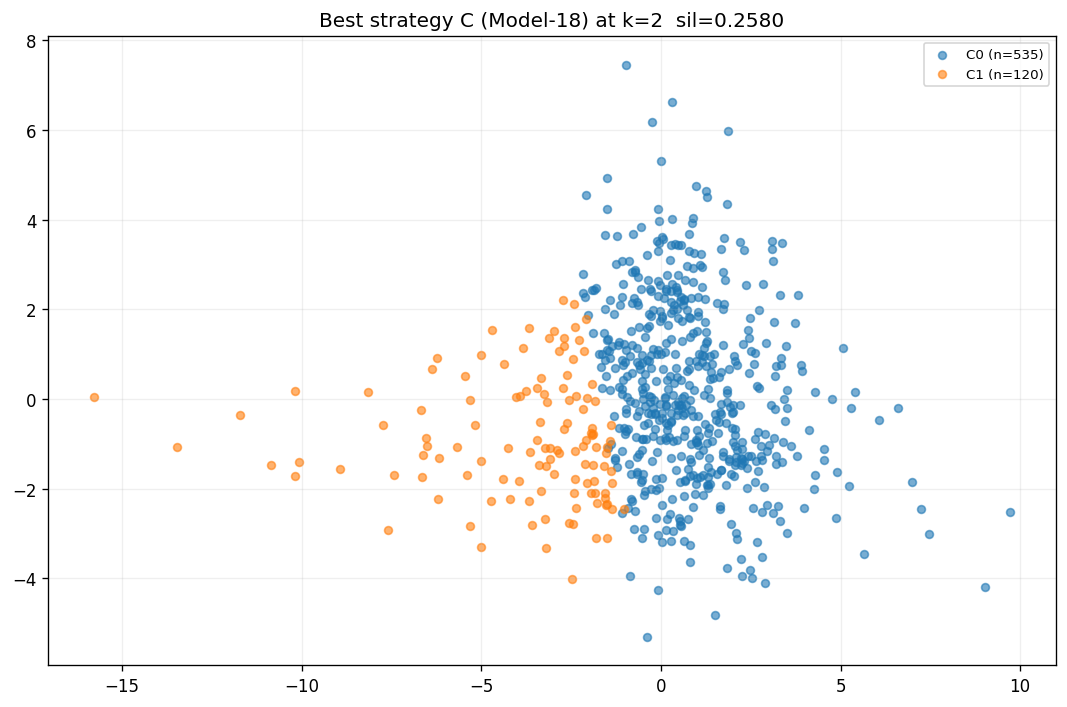

In [10]:
all_sils = {'A': sil_a, 'B': sil_b, 'C': sil_c}
all_Xs   = {'A': X_a,   'B': X_b,   'C': X_c}

print('Best k for each strategy:')
for name, sils in all_sils.items():
    best_k = k_list[int(np.argmax(sils))]
    print(f'  {name}: best k={best_k}  silhouette={max(sils):.4f}  (at k=5: {sils[3]:.4f})')

# For the overall best strategy, fit and visualise at its optimal k if different from 5
best_sils      = [sil_a, sil_b, sil_c][best_idx]
best_k_overall = k_list[int(np.argmax(best_sils))]

if best_k_overall != 5:
    print(f'\nFitting best strategy at k={best_k_overall}...')
    km_bk    = KMeans(n_clusters=best_k_overall, n_init=50, max_iter=500, random_state=RANDOM_STATE)
    lbl_bk   = km_bk.fit_predict(best_X)
    pca      = PCA(n_components=2, random_state=RANDOM_STATE)
    coords   = pca.fit_transform(best_X)
    fig, ax  = plt.subplots(figsize=(9, 6))
    for k_id in range(best_k_overall):
        mask = lbl_bk == k_id
        ax.scatter(coords[mask, 0], coords[mask, 1], alpha=0.6, s=22,
                   label=f'C{k_id} (n={mask.sum()})')
    ax.set_title(f'Best strategy {best_name} at k={best_k_overall}  sil={max(best_sils):.4f}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print(f'\nk=5 is already optimal for the best strategy.')

## 9. Summary & Recommendation

In [11]:
print('=' * 68)
print('SUMMARY')
print('=' * 68)
for name, sils in [('A (original 22, 2019-2021)      ', sil_a),
                   ('B (extended monthly, 2019-2024)  ', sil_b),
                   ('C (model-18 means, 2019-2024)    ', sil_c)]:
    bk = k_list[int(np.argmax(sils))]
    print(f'  {name}  sil@k=5={sils[3]:.4f}  best={max(sils):.4f}@k={bk}')

print()
print(f'ZIP reassignment B vs A: {round((1-rate_ab)*n)}/{n} ZIPs changed ({(1-rate_ab):.1%})')
print(f'ZIP reassignment C vs A: {round((1-rate_ac)*n)}/{n} ZIPs changed ({(1-rate_ac):.1%})')
print()
print('RECOMMENDATION:')
delta = max(sils_at_5) - sil_a[3]
if delta > 0.05:
    print(f'  Silhouette improves by {delta:.4f} ({best_name}) — strong case to update app clusters.')
elif delta > 0.01:
    print(f'  Silhouette improves by {delta:.4f} ({best_name}) — marginal gain.')
    print('  Update only if the new cluster stories are also more interpretable.')
else:
    print(f'  Silhouette change is minimal ({delta:+.4f}) — original clusters hold up well.')
    print('  If ZIP reassignment is significant, review whether new archetypes are more interpretable.')

SUMMARY
  A (original 22, 2019-2021)        sil@k=5=0.1210  best=0.1410@k=2
  B (extended monthly, 2019-2024)    sil@k=5=0.1142  best=0.2576@k=2
  C (model-18 means, 2019-2024)      sil@k=5=0.1630  best=0.2580@k=2

ZIP reassignment B vs A: 271/655 ZIPs changed (41.4%)
ZIP reassignment C vs A: 345/655 ZIPs changed (52.7%)

RECOMMENDATION:
  Silhouette improves by 0.0420 (C (Model-18)) — marginal gain.
  Update only if the new cluster stories are also more interpretable.
